# Exercises

## Exercise 1
---

You can find below the code that was used to generate the activity of place cells on a linear track.
Use the code and the decoding procedure you lerned about in the lesson to explore how different features of the data impact our ability to decode position.
In particular:

A - Try to use different fractions of our data samples. How does the median error change when the the number of available sample gets larger? You do not need to re-generate any data, just randomly sub-sample the data to different fractions.

B - How many place cells do we need to reliably decode position? Try to re-do the decoding using only 10 cell, then 20, and so on. How does the median error change? Does it reach an asymptote? (Also in this case, you do not need to re-generate the data, you can just select a random subset of cells each time)

C - Generate new data using the code below, changing the firing rate noise (changing the value of the variable `noise firing_rate`). How does this noise impact the decoding? 

In [44]:
import pickle

data_file = 'data/linear_track_data.pickle'
with open(data_file, 'rb') as handle:
    data = pickle.load(handle)

x,t,spikes = data['x'],data['t'],data['spikes']
track_length = data['track_length']
fps = data['fps'] 
n_cells = len(spikes)

In [45]:
import numpy as np

# we compute the poistion at which each spike was emitted
spike_positions = [np.interp(s, t, x) for s in spikes]
space_bins = np.arange(0., track_length, 5.) # binning in bins of 5 cms

# we compute histograms for each cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
spikes_hist = np.asarray(spikes_hist)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

spikes_count= [np.histogram(s,t)[0] for s in spikes]
spikes_count = np.asarray(spikes_count).T # we transpose the matrix to have the more familiar (samples x features) shape

501 cells used for decoding
Fraction of cells used for decoding: 0.1
5027


100%|██████████| 500/500 [00:00<00:00, 867.39it/s]


Median error: 57.3526455026455 cm


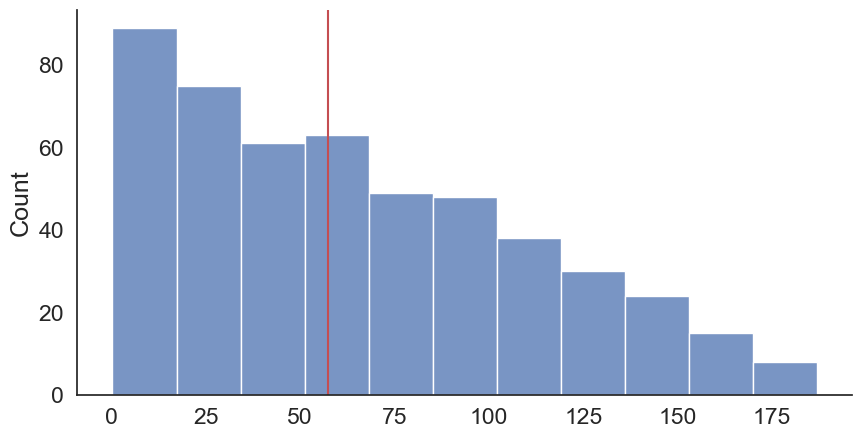

2512 cells used for decoding
Fraction of cells used for decoding: 0.5
5027


100%|██████████| 2511/2511 [00:02<00:00, 857.91it/s]


Median error: 60.5 cm


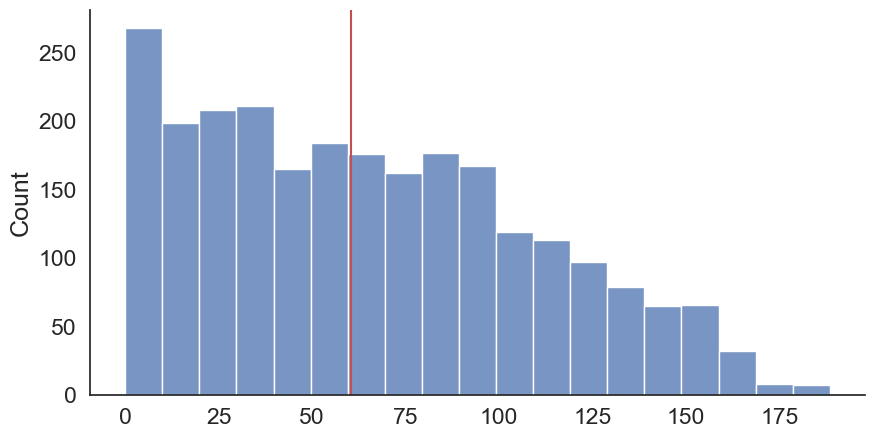

3517 cells used for decoding
Fraction of cells used for decoding: 0.7
5027


100%|██████████| 3516/3516 [00:04<00:00, 843.80it/s]

Median error: 55.02506265664158 cm


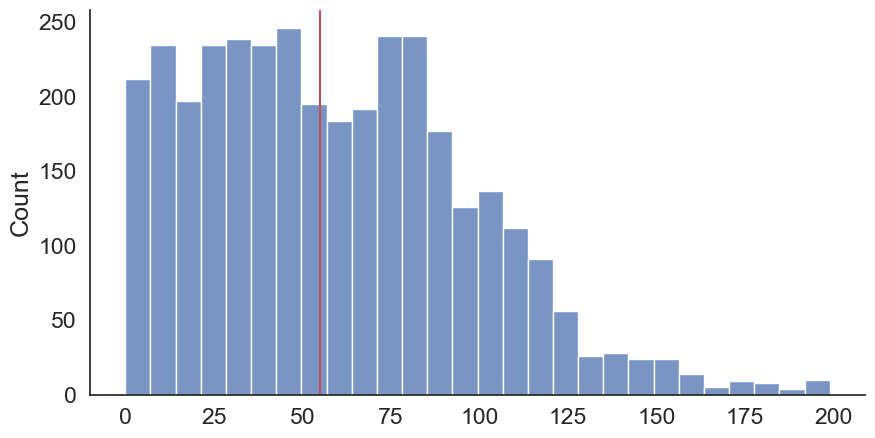

5000 cells used for decoding
Fraction of cells used for decoding: 0.995
5027


100%|██████████| 4999/4999 [00:05<00:00, 860.31it/s]


Median error: 8.276194029850743 cm


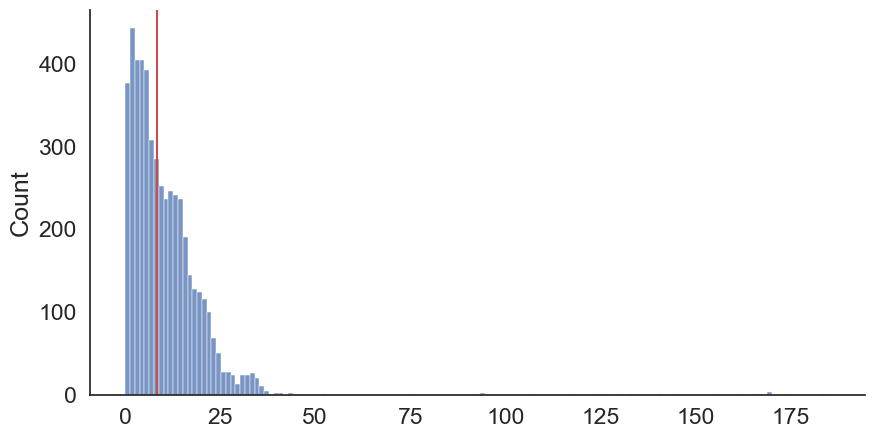

5026 cells used for decoding
Fraction of cells used for decoding: 1.0
5027


100%|██████████| 5025/5025 [00:05<00:00, 850.90it/s]


Median error: 3.343434343434353 cm


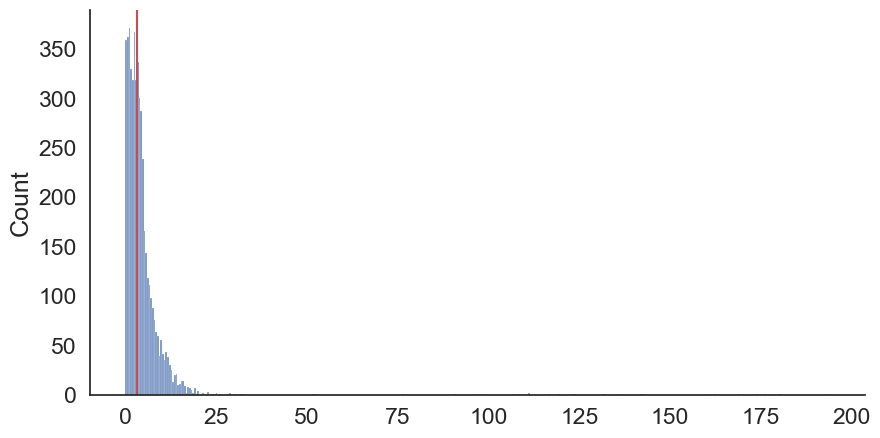

In [46]:
# 1 A

# code decoding
from tqdm import tqdm
from scipy.stats import poisson
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})



for fraction in [0.1, 0.5, 0.7, 0.995, 1.0]:
    n_sub = int(len(t) * fraction) - 1
    random_indices = np.random.choice(
        np.arange(len(t)),
        size=n_sub,
        replace=False
    )
    random_indices = np.sort(random_indices) # sort indices to have them in order of time

    print(len(random_indices), 'cells used for decoding')
    print('Fraction of cells used for decoding:', fraction)
    print(len(t))

    x_sliced = x[random_indices]
    t_sliced = t[random_indices]

    true_x = x_sliced[:-1] # get rid of last timepoint to have same length as binned spikes
    decoding_times = t_sliced[:-1]

    x_decoded = np.zeros_like(true_x)

    for t_bin in tqdm(range(len(decoding_times))):
        if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
            posterior = np.empty(firing_rate_maps.shape[-1])

            for i in range(len(posterior)):
                # Note that we work with log so that we can sum probabilities
                # instead of multiplying them 
                #posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
                posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))


            x_decoded[t_bin] = space_bins[np.argmax(posterior)]
        else:
            x_decoded[t_bin] = np.nan

    # error distribution
    mse = np.sqrt((true_x-x_decoded)**2)
    sns.histplot(mse)
    plt.axvline(x = np.nanmedian(mse),c='r')
    print(f'Median error: {np.nanmedian(mse)} cm')   
    plt.show()

The median error moves towards 0 as the N samples get larger. 
Makes sense, as we become more certain of the true value as we take into account more varying data.

100%|██████████| 5020/5020 [00:06<00:00, 795.57it/s]


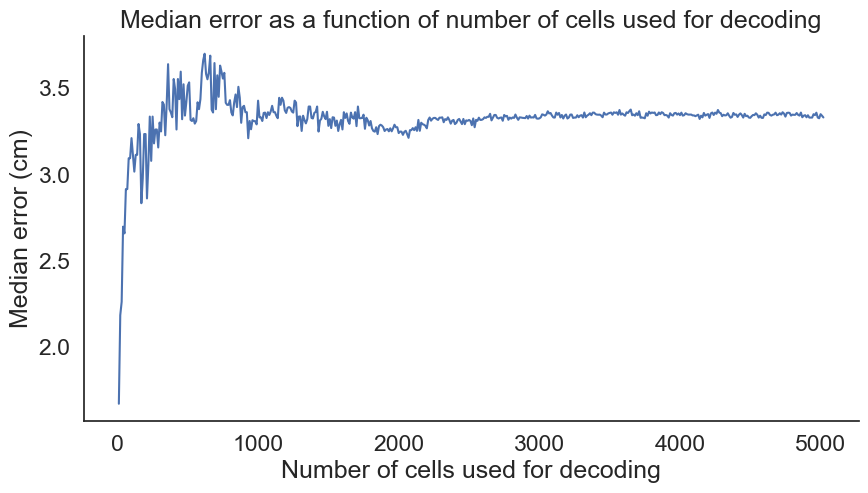

In [47]:
# 1 B

mses = []

for cell_count in np.arange(12, len(t), 10):
    n_sub = int(cell_count * fraction) - 1
    random_indices = np.random.choice(
        np.arange(cell_count),
        size=n_sub,
        replace=False
    )
    random_indices = np.sort(random_indices) # sort indices to have them in order of time

    x_sliced = x[random_indices]
    t_sliced = t[random_indices]

    true_x = x_sliced[:-1] # get rid of last timepoint to have same length as binned spikes
    decoding_times = t_sliced[:-1]

    x_decoded = np.zeros_like(true_x)

    for t_bin in tqdm(range(len(decoding_times))):
        if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
            posterior = np.empty(firing_rate_maps.shape[-1])

            for i in range(len(posterior)):
                # Note that we work with log so that we can sum probabilities
                # instead of multiplying them 
                #posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
                posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))


            x_decoded[t_bin] = space_bins[np.argmax(posterior)]
        else:
            x_decoded[t_bin] = np.nan

    mse = np.sqrt((true_x-x_decoded)**2)
    mses.append(np.nanmedian(mse))

plt.plot(np.arange(10, len(t), 10), mses)
plt.xlabel('Number of cells used for decoding')
plt.ylabel('Median error (cm)')
plt.title('Median error as a function of number of cells used for decoding')
plt.show()

It depends on how you define stable. But aroundd 200 cells does it reach the stable valuue, at 1000 cells does it also stabilize this value and from 2000 cells it becomes much less noisy.

### Code for data generation

In [54]:
import numpy as np
import scipy
import scipy.stats
import scipy.io
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline 
plt.rcParams['figure.figsize'] = [10, 5]
from ipywidgets import interact
import ipywidgets as widgets


track_length = 200. # the length of our linear track (eg in centimeter)
average_firing_rate = 5 # the peak firing rate, averaged across the population 
n_cells = 100 # how many cells we are recording
pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
pf_size = np.random.gamma(10, size=n_cells) # the size (width) of the place fields, drawn randomly from a gamma distribution 
pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells) # the peak firing rate for each cell, drawn from an exponential distribution

In [55]:
bins = np.arange(0., 200.)
true_firing_rate_maps = np.zeros((n_cells, len(bins)))
for i in range(n_cells):
    true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))

In [56]:
# GENERATE TRAJECTORY

n_runs = 10
use_stops = False
av_running_speed = 10 # the average running speed (in cm/s)
fps = 10 # the number of "video frames" per second 
running_speed_a = np.random.chisquare(10, size=n_runs) # running speed in the two directions
running_speed_b = np.random.chisquare(10, size=n_runs) 

stopping_time_a = np.random.chisquare(15, size=n_runs) # the time the mouse will spend at the two ends of the track
stopping_time_b = np.random.chisquare(15, size=n_runs)

x = np.array([])


for i in range(n_runs):
    stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
    run_length = len(bins) * fps / running_speed_a[i]
    run1 = np.linspace(0., float(len(bins)-1), int(run_length))
    stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
    run_length = len(bins) * fps / running_speed_b[i]
    run2 = np.linspace(len(bins)-1., 0., int(run_length))
    if use_stops:
        x = np.concatenate((x, stop1, run1, stop2, run2))
    else:
         x = np.concatenate((x, run1, run2))
t = np.arange(len(x))/fps

In [57]:
# 1 C

sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
x_sampling = np.floor(np.interp(t_sampling, t, x))
noise_firing_rate = 0.9 # value is set to 0.9
spikes = []

for i in range(n_cells):
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)
    sp = np.argwhere(spikes_loc)
    t_sp = t_sampling[sp]
    spikes.append(t_sp)

In [66]:
import pickle

file_name = 'linear_track_data_noise_edited.pickle' # change this name when you save new data

out_data = {}
out_data['x'] = x
out_data['t'] = t
out_data['spikes'] = spikes
out_data['track_length'] = track_length
out_data['fps'] = fps

with open('data/'+file_name,'wb') as f:
    pickle.dump(out_data,f)

  0%|          | 0/4739 [00:00<?, ?it/s]

100%|██████████| 4739/4739 [00:05<00:00, 850.64it/s]


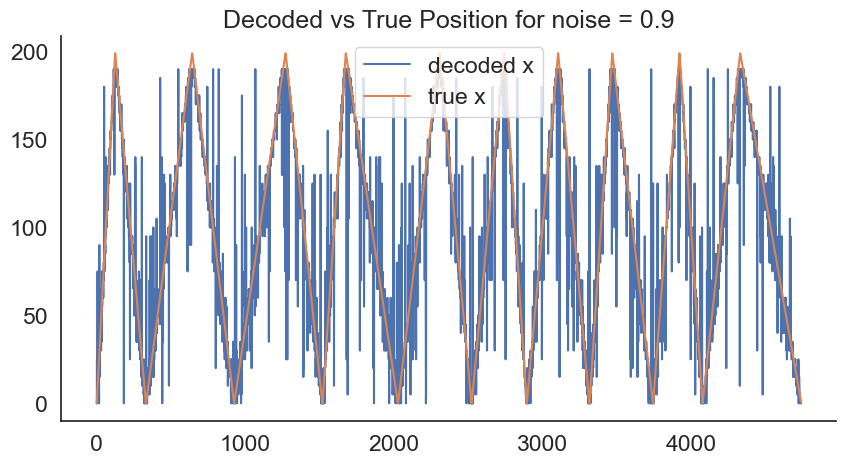

(4739,) (4739,)
Median error: 3.762589928057551 cm


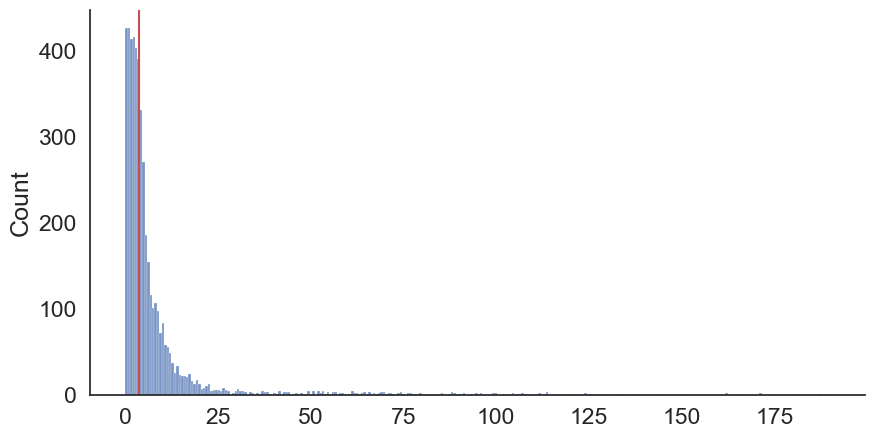

In [71]:
# 1 C
import pickle

data_file = 'data/linear_track_data_noise_edited.pickle'
with open(data_file, 'rb') as handle:
    data = pickle.load(handle)

x,t,spikes = data['x'],data['t'],data['spikes']
track_length = data['track_length']
fps = data['fps'] 
n_cells = len(spikes)

# we compute the poistion at which each spike was emitted
spike_positions = [np.interp(s, t, x) for s in spikes]
space_bins = np.arange(0., track_length, 5.) # binning in bins of 5 cms

# we compute histograms for each cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
spikes_hist = np.asarray(spikes_hist)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

spikes_count= [np.histogram(s,t)[0] for s in spikes]
spikes_count = np.asarray(spikes_count).T # we transpose the matrix to have the more familiar (samples x features) shape

# code decoding
from scipy.stats import poisson

true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
decoding_times = t[:-1]

x_decoded = np.zeros_like(true_x)

for t_bin in tqdm(range(len(decoding_times))):
    if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
        posterior = np.empty(firing_rate_maps.shape[-1])

        for i in range(len(posterior)):
            # Note that we work with log so that we can sum probabilities
            # instead of multiplying them 
            #posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
            posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))


        x_decoded[t_bin] = space_bins[np.argmax(posterior)]
    else:
        x_decoded[t_bin] = np.nan   

plt.figure(figsize=(10,5))
plt.plot(x_decoded,label= 'decoded x')
plt.plot(true_x,label = 'true x')
plt.title('Decoded vs True Position for noise = 0.9')
plt.legend()
plt.show()

# error distribution
print(true_x.shape, x_decoded.shape)

mse = np.sqrt((true_x-x_decoded)**2)
sns.histplot(mse)
plt.axvline(x = np.nanmedian(mse),c='r')
print(f'Median error: {np.nanmedian(mse)} cm')
plt.show()


  0%|          | 0/5026 [00:00<?, ?it/s]

100%|██████████| 5026/5026 [00:05<00:00, 863.74it/s]


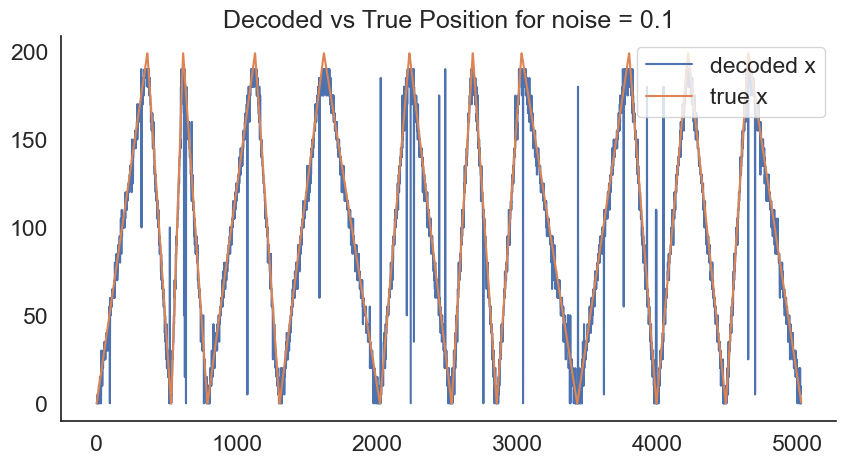

(5026,) (5026,)
Median error: 3.357155002380459 cm


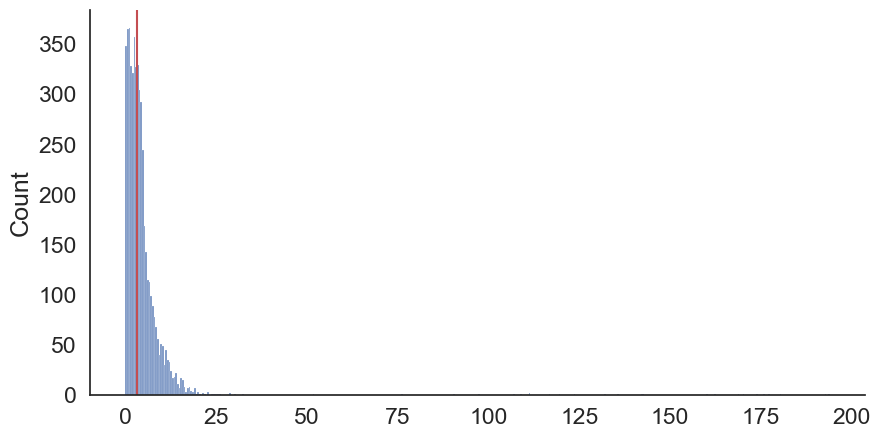

In [72]:
# 1 C
import pickle

data_file = 'data/linear_track_data.pickle'
with open(data_file, 'rb') as handle:
    data = pickle.load(handle)

x,t,spikes = data['x'],data['t'],data['spikes']
track_length = data['track_length']
fps = data['fps'] 
n_cells = len(spikes)

# we compute the poistion at which each spike was emitted
spike_positions = [np.interp(s, t, x) for s in spikes]
space_bins = np.arange(0., track_length, 5.) # binning in bins of 5 cms

# we compute histograms for each cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
spikes_hist = np.asarray(spikes_hist)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

spikes_count= [np.histogram(s,t)[0] for s in spikes]
spikes_count = np.asarray(spikes_count).T # we transpose the matrix to have the more familiar (samples x features) shape

# code decoding
from scipy.stats import poisson

true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
decoding_times = t[:-1]

x_decoded = np.zeros_like(true_x)

for t_bin in tqdm(range(len(decoding_times))):
    if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
        posterior = np.empty(firing_rate_maps.shape[-1])

        for i in range(len(posterior)):
            # Note that we work with log so that we can sum probabilities
            # instead of multiplying them 
            #posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
            posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))


        x_decoded[t_bin] = space_bins[np.argmax(posterior)]
    else:
        x_decoded[t_bin] = np.nan   

plt.figure(figsize=(10,5))
plt.plot(x_decoded,label= 'decoded x')
plt.plot(true_x,label = 'true x')
plt.title('Decoded vs True Position for noise = 0.1')
plt.legend()
plt.show()

# error distribution
print(true_x.shape, x_decoded.shape)

mse = np.sqrt((true_x-x_decoded)**2)
sns.histplot(mse)
plt.axvline(x = np.nanmedian(mse),c='r')
print(f'Median error: {np.nanmedian(mse)} cm')
plt.show()

for 1 C: as we can see, the noise increase from 0.1 to 0.9 yielded a very drastic randombess increase in the decoded positions. However, the median error did not change that much

## Exercise 2
---
In the loop implementation of the decoder, we used `poisson.logpmf(k,mu)` to calculate the log probability of observing $k$ spikes given an average firing rate of $\mu$. 
This is mathematically equivalent to `np.log(poisson.pmf(k,mu))`, in which we calculate the probability, and then take the log.


Re-run the decoding substituting this expression:

```
posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
```

To the line we are using to calculate the posterior.
Do you see any difference in the results? What do you think this is due to?




100%|██████████| 5026/5026 [00:06<00:00, 734.96it/s]


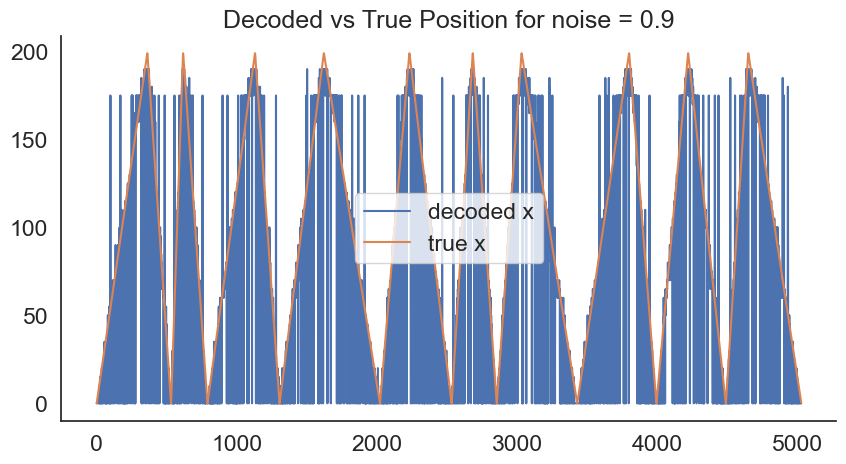

(5026,) (5026,)
Median error: 6.407201828099659 cm


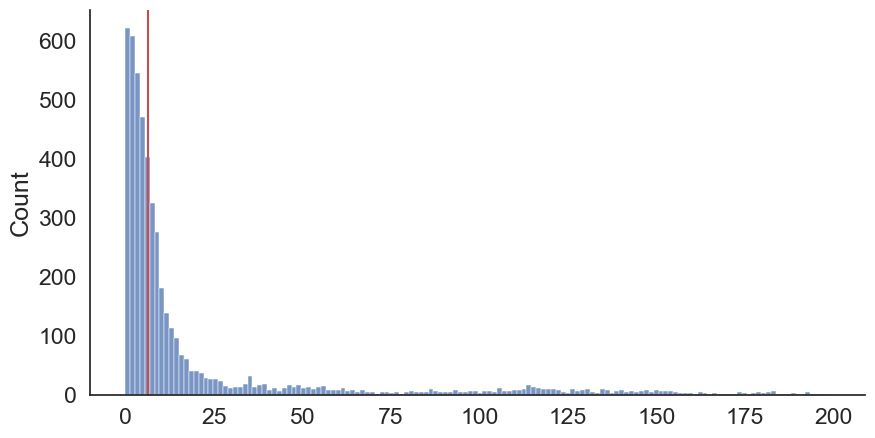

In [ ]:
# 2
import pickle

data_file = 'data/linear_track_data.pickle'
with open(data_file, 'rb') as handle:
    data = pickle.load(handle)

x,t,spikes = data['x'],data['t'],data['spikes']
track_length = data['track_length']
fps = data['fps'] 
n_cells = len(spikes)

# we compute the poistion at which each spike was emitted
spike_positions = [np.interp(s, t, x) for s in spikes]
space_bins = np.arange(0., track_length, 5.) # binning in bins of 5 cms

# we compute histograms for each cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
spikes_hist = np.asarray(spikes_hist)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

spikes_count= [np.histogram(s,t)[0] for s in spikes]
spikes_count = np.asarray(spikes_count).T # we transpose the matrix to have the more familiar (samples x features) shape

# code decoding
from scipy.stats import poisson

true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
decoding_times = t[:-1]

x_decoded = np.zeros_like(true_x)

for t_bin in tqdm(range(len(decoding_times))):
    if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
        posterior = np.empty(firing_rate_maps.shape[-1])

        for i in range(len(posterior)):
            # Note that we work with log so that we can sum probabilities
            # instead of multiplying them 
            posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
            posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))


        x_decoded[t_bin] = space_bins[np.argmax(posterior)]
    else:
        x_decoded[t_bin] = np.nan   

plt.figure(figsize=(10,5))
plt.plot(x_decoded,label= 'decoded x')
plt.plot(true_x,label = 'true x')
plt.title('Decoded vs True Position for noise = 0.9')
plt.legend()
plt.show()

# error distribution
print(true_x.shape, x_decoded.shape)

mse = np.sqrt((true_x-x_decoded)**2)
sns.histplot(mse)
plt.axvline(x = np.nanmedian(mse),c='r')
print(f'Median error: {np.nanmedian(mse)} cm')
plt.show()

So the original line was:          
"posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))"

I assumed the pow(1, -15) was an error and so, I changed it to:
"posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15)))"

Now this yielded very normal results and nothing out of the ordinary compared to:
"posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))"


But in case pow(1,-15) was as intended, here's what I observed:
While the change in median error isn't that big or even noticable at all, there is a massive change for the absolute values of decoded x. The data lines seem to follow the true x lines, but they always come down to the base level. That makes sense as 1**-15 is 1. That means that the log will compute (pmf + 1) rather than (pmf + 1e-15). Those are completely different calculations, which is what causes the strange jumparounds.

## Exercise 3
---
A - Estimate the quality of the sequence detection methods we saw in the lesson. How many false poistive does it find? How many false negatives?

B - Investigate the effect of `noise_x_react` and `noise_t_react` on the false positive rate and the false negative rate of our detection procedure.

C - What kind of sequence can our methods detect? What kind of activity, despide being sequential, could escape our detection method? Would you have an idea for a different method for sequence detection?

C:\Users\Emiel\AppData\Local\Temp\ipykernel_35816\2339812588.py:104: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = pearsonr(np.arange(len(x_decoded)),x_decoded)


<Axes: ylabel='Count'>

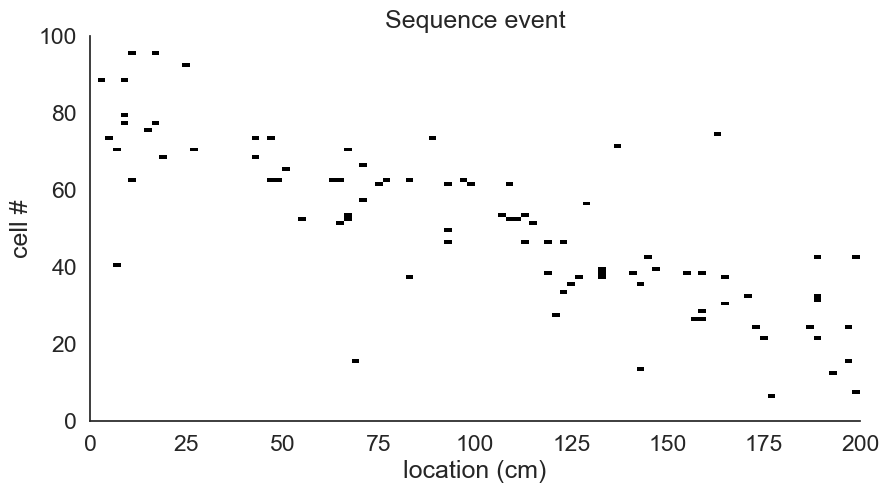

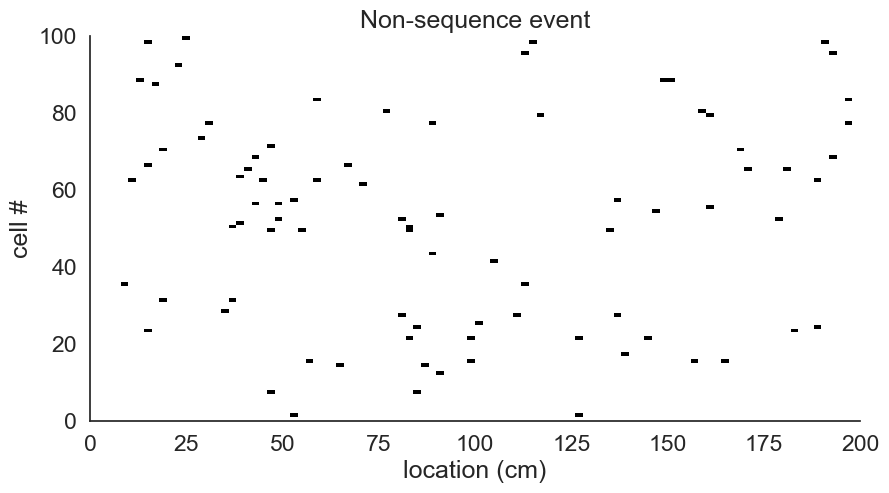

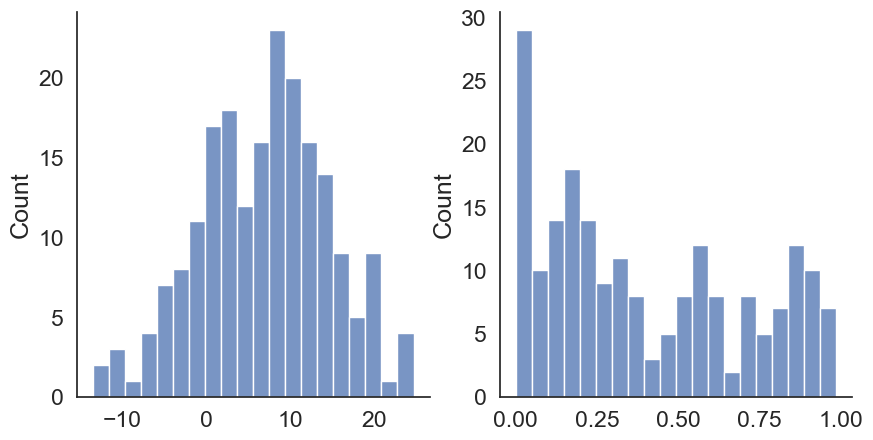

In [ ]:
from scipy.stats import pearsonr


# generate data 

n_events = 200 # number of reactivation events
event_duration = 100 # in bins
sampling_rate = 100 # sampling rate 
t_react = np.arange(0,100)
noise_x_react=5; # Noise in the reactivation of the sequence
noise_t_react=5; # Noise in the timing of the spikes 
noise_firing_rate = 0.1 # the baseline noise firing rate


reactivation_events = np.zeros((n_events,event_duration))
spikes_react = np.zeros((n_events,n_cells,event_duration))

for event in range(n_events):
    if(event<=n_events//2):
    #Generate "real" sequences for the first half of events
        x_start = np.random.uniform(0,track_length) # Starting point
        x_end = np.random.uniform(0,track_length) # Ending point
        x_react = np.linspace(x_start,x_end,event_duration) \
            +np.random.normal(0,noise_x_react,size=event_duration)

    else:
        #Pick locations randomly for the second half 
        x_react = np.random.uniform(0,track_length,size=event_duration);

    x_react[x_react<0]=0;
    x_react[x_react>track_length]=track_length
    
    #store reactivation sequence
    reactivation_events[event,:] = x_react

    
    # Generate spikes according to the location being reactivated in this event
    
    for i in range(n_cells):
        binned_x = np.digitize(x_react,bins=np.linspace(0,track_length,firing_rate_maps.shape[-1]))-1
        inst_rate = firing_rate_maps[i,binned_x] + np.random.normal(0,noise_firing_rate,size=len(binned_x))
        inst_rate[inst_rate<0] = 0
        spikes_loc = np.where(np.random.poisson(inst_rate/sampling_rate)>0)
        spikes_loc = spikes_loc + np.round(np.random.normal(0,noise_t_react,size=len(spikes_loc)))
        spikes_loc = spikes_loc[np.logical_and(spikes_loc>0,spikes_loc<event_duration)]
        spikes_react[event,i,spikes_loc.astype(int)] = 1


pfc_idxs = [np.argmax(rate_map) for rate_map in firing_rate_maps] 
sorted_idxs = np.argsort(pfc_idxs)


event = 50
plt.figure(figsize=(10,5))
plt.title('Sequence event')
plt.imshow(spikes_react[event,sorted_idxs,:], cmap='Greys', extent = [0, 200, 0, n_cells])
plt.xlabel('location (cm)')
plt.ylabel('cell #')

event = 150
plt.figure(figsize=(10,5))
plt.title('Non-sequence event')
plt.imshow(spikes_react[event,sorted_idxs,:], cmap='Greys', extent = [0, 200, 0, n_cells])
plt.xlabel('location (cm)')
plt.ylabel('cell #')


# to do: bayesian decoding
t_resize = 10 # We use spikes from multiple time windows for the decoding

reactivation_slopes = np.zeros(n_events)
reactivation_pvalues = np.zeros(n_events)

for event in range(n_events):

    event_spikes = spikes_react[event]
    spikes_sampled = np.zeros((n_cells,event_spikes.shape[1]//t_resize))

    # We generate a new spike matrix with the re-sized window
    for t_r in range(1,event_spikes.shape[1]//t_resize):
        spikes_sampled[:,t_r] = np.sum(event_spikes[:,(t_r-1)*t_resize :(t_r)*t_resize],axis=1)


    # We then perform decoding on the aggregated spikes
    x_decoded = np.zeros(spikes_sampled.shape[1])

    for t_bin in range(spikes_sampled.shape[1]):

        if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes

            posterior = np.empty(firing_rate_maps.shape[-1])
            for i in range(len(posterior)):
                posterior[i] = sum(poisson.logpmf(spikes_sampled[:,t_bin],firing_rate_maps[:,i]*t_resize/fps)+pow(1,-15))

            x_decoded[t_bin] = space_bins[np.argmax(posterior)]

        else:
            x_decoded[t_bin] = np.nan   

        # We fit a line to the decoded positions, and save the slope
        slope,_ = np.polyfit(np.arange(len(x_decoded)),x_decoded,deg=1)
        reactivation_slopes[event] = slope
        # And calculate the pvalue of the pearson correlation
        corr = pearsonr(np.arange(len(x_decoded)),x_decoded)
        reactivation_pvalues[event] = corr[1]


plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(reactivation_slopes,bins=20)
plt.subplot(1,2,2)
sns.histplot(reactivation_pvalues,bins=20)

In [82]:
# 3 A
threshold = 0.05
detected = reactivation_pvalues < threshold

fp = np.sum(detected[n_events//2 : ])  
fn = np.sum(~detected[: n_events//2])

print(f'False positives: {fp}')
print(f'False negatives: {fn}')

False positives: 14
False negatives: 86


I estimate there to be around 10% false positives and 90% false negatives

C:\Users\Emiel\AppData\Local\Temp\ipykernel_35816\1310774659.py:93: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = pearsonr(np.arange(len(x_decoded)),x_decoded)


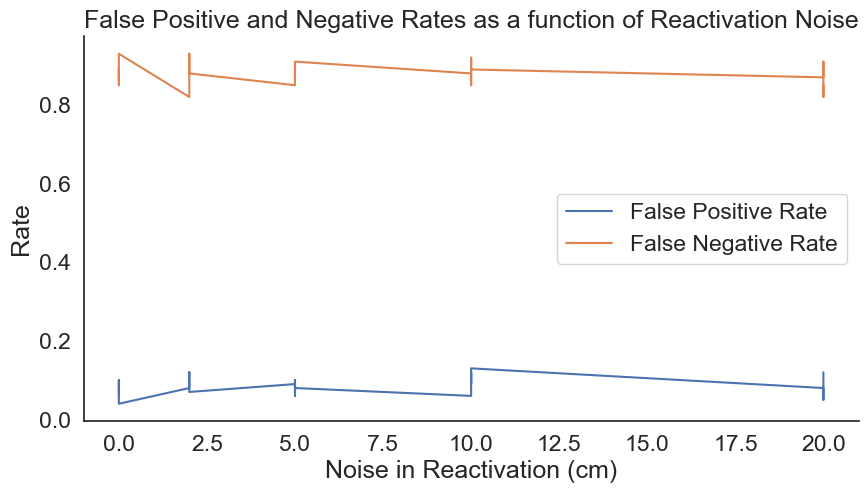

In [84]:
# 3 B

results = []
for noise_x in [0,2,5,10,20]:
    for noise_t in [0,2,5,10,20]:
        # generate data 

        n_events = 200 # number of reactivation events
        event_duration = 100 # in bins
        sampling_rate = 100 # sampling rate 
        t_react = np.arange(0,100)
        noise_x_react=noise_x; # Noise in the reactivation of the sequence
        noise_t_react=noise_t; # Noise in the timing of the spikes 
        noise_firing_rate = 0.1 # the baseline noise firing rate


        reactivation_events = np.zeros((n_events,event_duration))
        spikes_react = np.zeros((n_events,n_cells,event_duration))

        for event in range(n_events):
            if(event<=n_events//2):
            #Generate "real" sequences for the first half of events
                x_start = np.random.uniform(0,track_length) # Starting point
                x_end = np.random.uniform(0,track_length) # Ending point
                x_react = np.linspace(x_start,x_end,event_duration) \
                    +np.random.normal(0,noise_x_react,size=event_duration)

            else:
                #Pick locations randomly for the second half 
                x_react = np.random.uniform(0,track_length,size=event_duration);

            x_react[x_react<0]=0;
            x_react[x_react>track_length]=track_length
            
            #store reactivation sequence
            reactivation_events[event,:] = x_react

            
            # Generate spikes according to the location being reactivated in this event
            
            for i in range(n_cells):
                binned_x = np.digitize(x_react,bins=np.linspace(0,track_length,firing_rate_maps.shape[-1]))-1
                inst_rate = firing_rate_maps[i,binned_x] + np.random.normal(0,noise_firing_rate,size=len(binned_x))
                inst_rate[inst_rate<0] = 0
                spikes_loc = np.where(np.random.poisson(inst_rate/sampling_rate)>0)
                spikes_loc = spikes_loc + np.round(np.random.normal(0,noise_t_react,size=len(spikes_loc)))
                spikes_loc = spikes_loc[np.logical_and(spikes_loc>0,spikes_loc<event_duration)]
                spikes_react[event,i,spikes_loc.astype(int)] = 1


        pfc_idxs = [np.argmax(rate_map) for rate_map in firing_rate_maps] 
        sorted_idxs = np.argsort(pfc_idxs)

        event = 50
        event = 150

        # to do: bayesian decoding
        t_resize = 10 # We use spikes from multiple time windows for the decoding

        reactivation_slopes = np.zeros(n_events)
        reactivation_pvalues = np.zeros(n_events)

        for event in range(n_events):

            event_spikes = spikes_react[event]
            spikes_sampled = np.zeros((n_cells,event_spikes.shape[1]//t_resize))

            # We generate a new spike matrix with the re-sized window
            for t_r in range(1,event_spikes.shape[1]//t_resize):
                spikes_sampled[:,t_r] = np.sum(event_spikes[:,(t_r-1)*t_resize :(t_r)*t_resize],axis=1)


            # We then perform decoding on the aggregated spikes
            x_decoded = np.zeros(spikes_sampled.shape[1])

            for t_bin in range(spikes_sampled.shape[1]):

                if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes

                    posterior = np.empty(firing_rate_maps.shape[-1])
                    for i in range(len(posterior)):
                        posterior[i] = sum(poisson.logpmf(spikes_sampled[:,t_bin],firing_rate_maps[:,i]*t_resize/fps)+pow(1,-15))

                    x_decoded[t_bin] = space_bins[np.argmax(posterior)]

                else:
                    x_decoded[t_bin] = np.nan   

                # We fit a line to the decoded positions, and save the slope
                slope,_ = np.polyfit(np.arange(len(x_decoded)),x_decoded,deg=1)
                reactivation_slopes[event] = slope
                # And calculate the pvalue of the pearson correlation
                corr = pearsonr(np.arange(len(x_decoded)),x_decoded)
                reactivation_pvalues[event] = corr[1]

        threshold = 0.05
        detected = reactivation_pvalues < threshold

        fp = np.sum(detected[n_events//2 : ])  
        fn = np.sum(~detected[: n_events//2])

        fp_rate = fp/100
        fn_rate = fn/100

        results.append((noise_x, noise_t, fp_rate, fn_rate))

plt.figure(figsize=(10,5))
plt.plot([r[0] for r in results], [r[2] for r in results], label='False Positive Rate')
plt.plot([r[0] for r in results], [r[3] for r in results], label='False Negative Rate')
plt.xlabel('Noise in Reactivation (cm)')
plt.ylabel('Rate')
plt.title('False Positive and Negative Rates as a function of Reactivation Noise')
plt.legend()
plt.show()
      

It appears as though the noise in reactivation does not havev a very big effect on the fp and fn rates, as these all remain fairly stable over time.
What can be seen however is that at low noise in reactivation the FP rates attempt to go down very strongly, whereas the FN rates attempt to go up. Then the slope for both decreases as the noise gets larger, and for the FP rates, it even starts moving the slope towards 0 again.

3 C:

The pipeline contains a bayesian decoder, linear fit and pearson r/p-value. 
So the decoder is most sensitive to constant, linear signals.

The types of activity that can escape is non-linear trajectories, variable-speed replays, sparce/partial sequences and mixed coding ensembles.

We simply rank neurons by their favorite spot on the track and then check if they fire in that same order—if the firing order lines up with their place‐field order, it’s a sequence.